# IMDB Top 1000 Movies: Exploratory Data Analysis
**Author:** Tousif Aziz Khan
**Links:** [GitHub](https://github.com/Tousif2007) | [LinkedIn](https://linkedin.com/in/tousif-khan07)
**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

### Project Overview
This project analyzes data from the top 1000 highest-rated movies showing how a movie's runtime, critical reception ('Meta_score'), and audience ratings ('IMDB_Rating') impact its overall financial success ('Gross').

### Core Objectives
* **Data Wrangling and Transformation:** Clean and convert unstructured string columns (e.g., stripping "min" from 'Runtime' and commas from 'Gross' revenue) into clean numeric formats for analysis.

* **Statistical Analysis:** Identify key correlations between critical reception ('Meta_score'), audience ratings ('IMDB_Rating'), and financial success ('Gross').


In [9]:
# First, we import pandas for data loading and cleaning
import pandas as pd 

# We import numpy for numerical and mathematical operations
import numpy as np 

# We import matplotlib for creating core data visualizations
import matplotlib.pyplot as plt 

# We import seaborn for advanced and styled statistical plots
import seaborn as sns

# Lets configure seaborn to use a clean grid background for all charts
sns.set_theme(style="whitegrid")

# Printing status message confirming successful setup
print("Libraries imported and visualization theme set successfully")

Libraries imported and visualization theme set successfully


In [10]:
# Loading the raw movie data from the CSV file into a pandas data frame
df = pd.read_csv('imdb_top_1000.csv')

# Display the first 5 rows of the data frame to inspect columns and values
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [11]:
# Check structural details including data types, row counts, and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 520.0 KB


In [12]:
# Count exactly how many missing (null) values exist in each column
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [13]:
# Check the exact dimensions of the dataset (rows, columns)
df.shape

(1000, 16)

In [14]:
# strip the 'min' text from runtime and convert the column to integers
df['Runtime'] = df['Runtime'].str.replace('min', '').astype(int)

# Display the first 5 rows to verify the column was successfully updated
df['Runtime'].head()

0    142
1    175
2    152
3    202
4     96
Name: Runtime, dtype: int64

In [15]:
# Remove commas from the Gross column and convert it to float numbers
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

# Display the first 5 rows to verify the column was successfully updated
df['Gross'].head()

0     28341469.0
1    134966411.0
2    534858444.0
3     57300000.0
4      4360000.0
Name: Gross, dtype: float64

In [16]:
# Generates descriptive statistics for all numeric columns
df.describe()

,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,1000.000000,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,122.891000,7.949300,77.971530,2.736929e+05,6.803475e+07
std,28.093671,0.275491,12.376099,3.273727e+05,1.097500e+08
min,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,103.000000,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,119.000000,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,137.000000,8.100000,87.000000,3.741612e+05,8.075089e+07
max,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


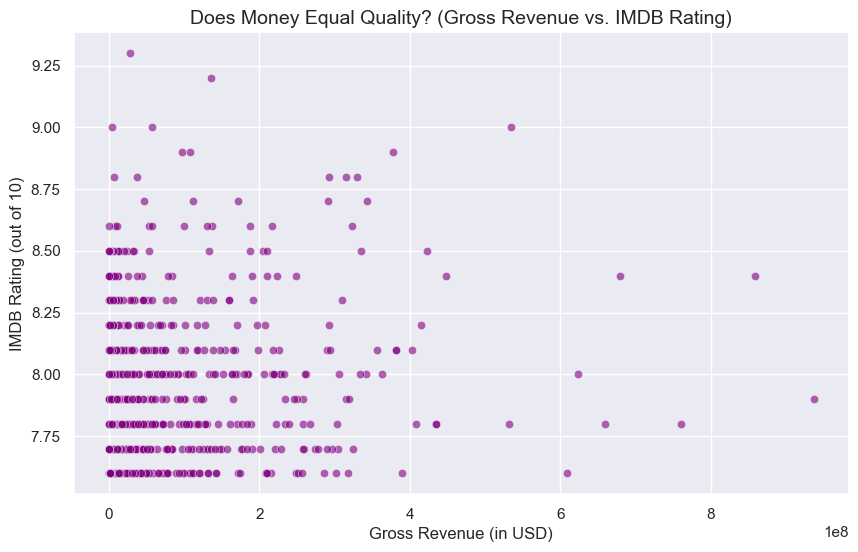

In [17]:
# to set a clean visual style for our chart
sns.set_theme(style="darkgrid")

# Creating a figure canvas (width=10 inches, height=6 inches)
plt.figure(figsize=(10,6))

#Drawing the scatter plot
sns.scatterplot(data=df, x='Gross', y='IMDB_Rating', alpha=0.6, color='purple')

#Giving the chart clear labels and a title
plt.title('Does Money Equal Quality? (Gross Revenue vs. IMDB Rating)', fontsize=14)
plt.xlabel('Gross Revenue (in USD)', fontsize=12)
plt.ylabel('IMDB Rating (out of 10)', fontsize=12)

# putting the plot on screen
plt.show()

